# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           60          |
|------------|----------------------|
| A. Tudor Berechet  |        6137946       |
| B. Luca-Adam Bledea-Floruta  |        6205682       |
| C. Alejandro Huguet Lorente  |        6145744       |
| D. Adam Pobudejski  |        6155332       |

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [2]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        actions = agent.get_valid_actions(maze=maze)
        return random.choice(actions)

    def e_greedy(self, agent: Agent,  maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        state = agent.get_state(maze=maze)
        actions = agent.get_valid_actions(maze=maze)

        p = np.random.random()
        if p < eps:                             # exploration
            action = random.choice(actions)
        else:                                   # explotation
            q_values = np.array([self.q_table.get_q(state=state, action=action) for action in actions])
            action = actions[np.argmax(q_values)]
        
        return action


    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """
        state = agent.get_state(maze=maze)
        actions = agent.get_valid_actions(maze=maze)
        
        # assign probability based on the formula 
        q_values = np.array([self.q_table.get_q(state=state, action=action) for action in actions])
    
        denominator = np.sum(np.exp(q_values / temperature))
        p_a = (np.exp(q_values / temperature) / denominator)

        return np.random.choice(actions, p=p_a)


<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

#### Question 2

In [3]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)
# Create an Agent.
agent = Agent(start_x=0, start_y=0)
# Create a QTable.
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)
# Create a learner.
params = {"lr": 0.7, "gamma": 0.9}
# learner = QLearning(q_table, params)

# Hyper-parameters.
def agent_cycle(n_episodes=300, strategy=0, eps=0.1, temperature=1.0):
    """
    Runs the agent through multiple episodes in the maze using a specified exploration strategy.

    Args:
        n_episodes (int, optional): Number of episodes to run. Defaults to 300.
        strategy (int, optional): Exploration strategy to use (0: random, 1: e-greedy, 2: Boltzmann). Defaults to 0.
        eps (float, optional): Epsilon value for e-greedy strategy. Defaults to 0.1.
        temperature (float, optional): Temperature parameter for Boltzmann strategy. Defaults to 1.0.

    Returns:
        - episode_lengths: List of episode lengths (number of steps per episode).
        - episode_rewards: List of total rewards obtained in each episode.
    """
    episode_lengths = []
    episode_rewards = []

    for episode in tqdm(range(n_episodes)):
        agent.reset()
        total_reward = 0
        total_length = 0

        while not agent.get_state(maze=maze).done:
            # 1. Get current state
            current_state = agent.get_state(maze=maze)
            
            # 2. Select an action (random, e_greedy, or boltzmann)
            if strategy == 0:
                action = exploration_strategy.random(agent, maze)
            elif strategy == 1:
                action = exploration_strategy.e_greedy(agent, maze, eps=eps)
            elif strategy == 2:
                action = exploration_strategy.boltzmann(agent, maze, temperature)

            # 3. Execute the action and move the agent
            next_state, reward, done = agent.step(action, maze)

            # 4. Call the learner (not yet implemented)
            # learner.learn(current_state, action, r, next_state)

            # 5. Update the total_reward/length
            total_reward += reward
            total_length += 1
        

        episode_rewards.append(total_reward)
        episode_lengths.append(total_length)

    return episode_lengths, episode_rewards


Steps

```java
for(int i = 0 ; i < n ; i++) {
    break;
}
```

#### Question 3

In [4]:
def agent_cycle_early_stop(n_episodes=300, strategy=0, eps=0.1, temperature=1.0, steps_criterion=30000):
    """
    Runs the agent through multiple episodes in the maze using a specified exploration strategy,
    with early stopping if the total number of steps exceeds a given criterion.

    Args:
        n_episodes (int, optional): Number of episodes to run. Defaults to 300.
        strategy (int, optional): Exploration strategy to use (0: random, 1: e-greedy, 2: Boltzmann). Defaults to 0.
        eps (float, optional): Epsilon value for e-greedy strategy. Defaults to 0.1.
        temperature (float, optional): Temperature parameter for Boltzmann strategy. Defaults to 1.0.
        steps_criterion (int, optional): Maximum total steps before early stopping. Defaults to 30000.

    Returns:
        - episode_lengths: List of episode lengths (number of steps per episode).
        - episode_rewards: List of total rewards obtained in each episode.
    """
    episode_lengths = []
    episode_rewards = []

    total_steps = 0 

    for episode in tqdm(range(n_episodes)):
        agent.reset()
        total_reward = 0
        total_length = 0

        while not agent.get_state(maze=maze).done:
            # 1. Get current state
            current_state = agent.get_state(maze=maze)
            
            # 2. Select an action (random, e_greedy, or boltzmann)
            if strategy == 0:
                action = exploration_strategy.random(agent, maze)
            elif strategy == 1:
                action = exploration_strategy.e_greedy(agent, maze, eps=eps)
            elif strategy == 2:
                action = exploration_strategy.boltzmann(agent, maze, temperature)

            # 3. Execute the action and move the agent
            next_state, reward, done = agent.step(action, maze)
            total_steps += 1

            # 4. Call the learner (not yet implemented)
            # learner.learn(current_state, action, r, next_state)

            # 5. Update the total_reward/length
            total_reward += reward
            total_length += 1

        episode_rewards.append(total_reward)
        episode_lengths.append(total_length)

        if total_steps > steps_criterion:
            break

    return episode_lengths, episode_rewards


<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._  
_You may want to directly modify the cycle in Question 2._

#### Question 4

Run number 1


100%|██████████| 300/300 [00:00<00:00, 335.44it/s]


Run number 2


100%|██████████| 300/300 [00:00<00:00, 345.81it/s]


Run number 3


...

100%|██████████| 300/300 [00:00<00:00, 304.84it/s]


Run number 9


100%|██████████| 300/300 [00:00<00:00, 329.15it/s]


Run number 10


100%|██████████| 300/300 [00:00<00:00, 335.44it/s]


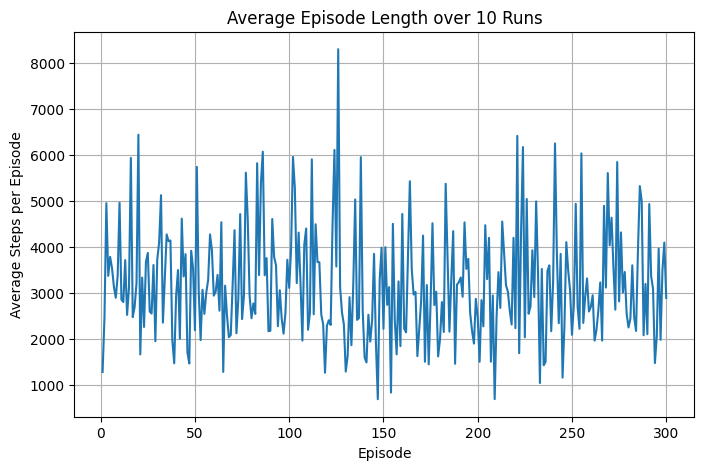

In [ ]:
all_lengths = []
for run in range(10):
    print("Run number " + str(run + 1))
    episode_lengths, episode_rewards = agent_cycle()
    all_lengths.append(episode_lengths)

min_episodes = min(len(length) for length in all_lengths)

avg_lengths = []
for ep in range(min_episodes):
    avg_lengths.append(np.mean([length[ep] for length in all_lengths]))

plt.figure(figsize=(8, 5))
plt.plot(range(1, min_episodes + 1), avg_lengths)
plt.xlabel('Episode')
plt.ylabel('Average Steps per Episode')
plt.title('Average Episode Length over 10 Runs')
plt.grid(True)
plt.show()

Regardless of the exploration strategy (random, ε‑greedy, or Boltzmann), the agent does not learn because the Q‑values are never updated, hence we can just use the random strategy.

Run number 1


100%|██████████| 300/300 [00:00<00:00, 307.54it/s]


Run number 2


100%|██████████| 300/300 [00:00<00:00, 399.23it/s]


Run number 3


...

100%|██████████| 300/300 [00:00<00:00, 378.58it/s]


Run number 9


100%|██████████| 300/300 [00:00<00:00, 336.54it/s]


Run number 10


100%|██████████| 300/300 [00:00<00:00, 371.88it/s]


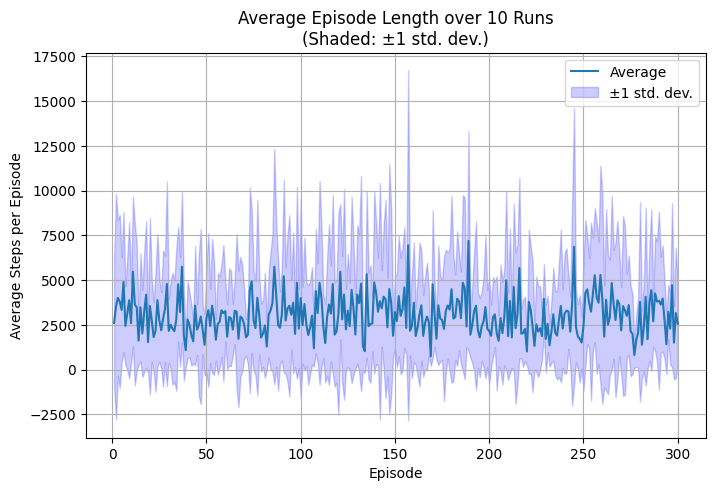

In [6]:
all_lengths = []
for run in range(10):
    print("Run number " + str(run + 1))
    episode_lengths, episode_rewards = agent_cycle()
    all_lengths.append(episode_lengths)

min_episodes = min(len(length) for length in all_lengths)

# Compute averages and standard deviations
avg_lengths = []
std_lengths = []
for ep in range(min_episodes):
    episode_steps = [length[ep] for length in all_lengths]
    avg_lengths.append(np.mean(episode_steps))
    std_lengths.append(np.std(episode_steps))

avg_lengths = np.array(avg_lengths)
std_lengths = np.array(std_lengths)

plt.figure(figsize=(8, 5))
plt.plot(range(1, min_episodes + 1), avg_lengths, label='Average')
plt.fill_between(
    range(1, min_episodes + 1),
    avg_lengths - std_lengths,
    avg_lengths + std_lengths,
    color='b',
    alpha=0.2,
    label='±1 std. dev.'
)
plt.xlabel('Episode')
plt.ylabel('Average Steps per Episode')
plt.title('Average Episode Length over 10 Runs\n(Shaded: ±1 std. dev.)')
plt.grid(True)
plt.legend()
plt.show()

Run number 1


100%|██████████| 300/300 [00:09<00:00, 31.20it/s]


Run number 2


100%|██████████| 300/300 [00:10<00:00, 29.79it/s]


Run number 3


...

100%|██████████| 300/300 [00:08<00:00, 33.45it/s]


Run number 9


100%|██████████| 300/300 [00:09<00:00, 31.32it/s]


Run number 10


100%|██████████| 300/300 [00:10<00:00, 28.10it/s]


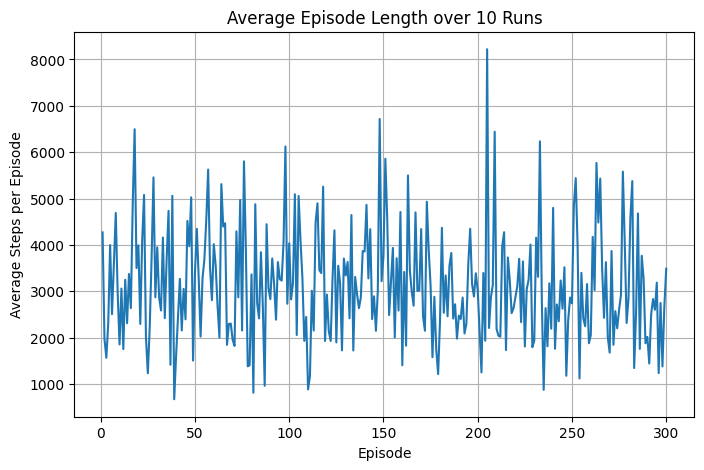

In [8]:
all_lengths = []
for run in range(10):
    print("Run number " + str(run + 1))
    episode_lengths, episode_rewards = agent_cycle(strategy=2)
    all_lengths.append(episode_lengths)

min_episodes = min(len(length) for length in all_lengths)

avg_lengths = []
for ep in range(min_episodes):
    avg_lengths.append(np.mean([length[ep] for length in all_lengths]))

plt.figure(figsize=(8, 5))
plt.plot(range(1, min_episodes + 1), avg_lengths)
plt.xlabel('Episode')
plt.ylabel('Average Steps per Episode')
plt.title('Average Episode Length over 10 Runs')
plt.grid(True)
plt.show()

#### Question 5

In [ ]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        pass

In [ ]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        pass

<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

#### Question 6

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 7

<div style="background-color:#f1be3e">

_Write your answer here._

### 2.2 Optimization
#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 9

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.3 Introducing More Rewards
#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper
#### Question 20


![Q_20](Q_20.png)


**States**:
- E - at the entrance without holding anything (starting point)
- A - at the aisle without holding anything
- C - at the cash register without holding anything
- EB2 - at the entrance holding 2 packs of berries
- AB2 - at the aisle holding 2 packs of berries
- CB2 - at the cash register holding 2 packs of berries
- EB1, AB1, CB1 - same as above but with 1 pack of berries
- EAP, AAP, CAP - same as above but with apples
- T - terminal state
	
**Actions**:
- F - move forward
- R - move backwards
- A - pick up apples
- B - pick up berries
- P - pay


**Remarks**:

F, 0.9, r=0 - move forward with probability 0.9 and result in reward 0.

As stated in the exercise, to avoid clustering, we omitted actions that do not change the state of the robot and just result in a "wasted" move (r = -1). However we did include the penalty caused by actuators failing in the state E to show understanding of how it would look like. Such transitions should be included in every state. Moreover, we included the penalty for spilling berries, as it results in a penalty of -2. 

#### Question 21

![Q_20](Q_21.png)


**Note**: The policy is only represented by the first 2 columns, as it just maps a satte to an action. The rest of the table is just to help with calculations.

Iteration 0 (initialization):

$$
\begin{aligned}
v_0(E) &= 0 \\
v_0(A) &= 0 \\
v_0(C) &= 0 \\
v_0(EB1) &= 0 \\
v_0(AB1) &= 0 \\
v_0(CB1) &= 0 \\
v_0(EB2) &= 0 \\
v_0(AB2) &= 0 \\
v_0(CB2) &= 0 \\
v_0(EAP) &= 0 \\
v_0(AAP) &= 0 \\
v_0(CAP) &= 0 \\
v_0(T) &= 0
\end{aligned}
$$

Iteration 1:

$$
\begin{aligned}
v_1(E) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(E)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(A) &= 1.0 \cdot [0 + 0.9 \cdot v_0(AB1)] = 1.0 \cdot [0 + 0.9 \cdot 0] = 0 \\
v_1(C) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(C)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(EB1) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(EB1)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(AB1) &= 0.8 \cdot [0 + 0.9 \cdot v_0(AB2)] + 0.2 \cdot [-2 + 0.9 \cdot v_0(AB1)] \\
&= 0.8 \cdot 0 + 0.2 \cdot (-2) \\
&= -0.4 \\
v_1(CB1) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(CB1)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(EB2) &= 0.9 \cdot [0 + 0.9 \cdot v_0(AB2)] + 0.1 \cdot [-1 + 0.9 \cdot v_0(EB2)] \\
&= 0.9 \cdot 0 + 0.1 \cdot (-1) \\
&= -0.1 \\
v_1(AB2) &= 0.9 \cdot [0 + 0.9 \cdot v_0(CB2)] + 0.1 \cdot [-1 + 0.9 \cdot v_0(AB2)] \\
&= 0.9 \cdot 0 + 0.1 \cdot (-1) \\
&= -0.1 \\
v_1(CB2) &= 1.0 \cdot [10 + 0.9 \cdot v_0(T)] = 1.0 \cdot [10 + 0] = 10 \\
v_1(EAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(EAP)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(AAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(AAP)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(CAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(CAP)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(T) &= v_0(T) = 0
\end{aligned}
$$

Iteration 2:

$$
\begin{aligned}
v_2(E) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(E)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(A) &= 1.0 \cdot [0 + 0.9 \cdot v_1(AB1)] = 0.9 \cdot (-0.4) = -0.36 \\
v_2(C) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(C)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(EB1) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(EB1)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(AB1) &= 0.8 \cdot [0 + 0.9 \cdot v_1(AB2)] + 0.2 \cdot [-2 + 0.9 \cdot v_1(AB1)] \\
&= 0.8 \cdot (0.9 \cdot (-0.1)) + 0.2 \cdot (-2 + 0.9 \cdot (-0.4)) \\
&= 0.8 \cdot (-0.09) + 0.2 \cdot (-2.36) \\
&= -0.072 - 0.472 = -0.544 \\
v_2(CB1) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(CB1)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(EB2) &= 0.9 \cdot [0 + 0.9 \cdot v_1(AB2)] + 0.1 \cdot [-1 + 0.9 \cdot v_1(EB2)] \\
&= 0.9 \cdot (0.9 \cdot (-0.1)) + 0.1 \cdot (-1 + 0.9 \cdot (-0.1)) \\
&= 0.9 \cdot (-0.09) + 0.1 \cdot (-1.09) \\
&= -0.081 - 0.109 = -0.19 \\
v_2(AB2) &= 0.9 \cdot [0 + 0.9 \cdot v_1(CB2)] + 0.1 \cdot [-1 + 0.9 \cdot v_1(AB2)] \\
&= 0.9 \cdot (0.9 \cdot 10) + 0.1 \cdot (-1 + 0.9 \cdot (-0.1)) \\
&= 0.9 \cdot 9 + 0.1 \cdot (-1.09) \\
&= 8.1 - 0.109 = 7.991 \\
v_2(CB2) &= 1.0 \cdot [10 + 0.9 \cdot v_1(T)] = 10 + 0 = 10 \\
v_2(EAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(EAP)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(AAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(AAP)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(CAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(CAP)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2​(T) &=v_1​(T)=0
\end{aligned}
$$

#### Question 22

In order to find the optimal policy, we can use **value iteration**. We run the 
Bellman optimality equation repeatedly for all states until the values converge 
(improvement stays below a threshold for consecutive iterations):

$$v_{k+1}(s) = \max_{a} \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma v_k(s') \right]$$

Instead of following a fixed policy like in Q21, we take the max over all actions 
at each state. At every iteration, for every state, we try all possible actions 
and keep the one with the highest expected value.

Similarly to Q21, we start with $v_0(s) = 0$. At the end we pick the policy 
greedily - at each state, take whichever action gave the maximum.

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**